In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.entities.client import ClientNode
from src.entities.qses import QSESNode
from src.entities.server import MedicalServerNode
from src.protocol.errors import MaliciousEdgeError, ProtocolError
from src.protocol.messages import ClientPacket, EdgePacket

def hexpreview(data: bytes, n: int = 16) -> str:
    h = data[:n].hex()
    return f"{h}... ({len(data)} bytes total)" if len(data) > n else f"{h} ({len(data)} bytes)"

print("Imports OK, project root:", project_root)

liboqs-python faulthandler is disabled
Imports OK, project root: /work


In [2]:
server = MedicalServerNode(server_id=9)
client = ClientNode(client_id=1, server_id=9, session_id=3, qses_nonce=222)
qses = QSESNode(server.public_key)      # server's kem public key for encapsulation 

qses.register_client(client.client_id, client.public_key)   # client ml-dsa key for signature verification 
server.trust_qses(qses.public_key)    # server will get qses ml-dsa key for verifications + client's ml-dsa for client pkt verification 
server.register_client(client.client_id, client.public_key, client.hmac_key, client.qses_nonce)  
#. hmac key to find out malicious key 
print("Medical Server ML-KEM-512 public key:", hexpreview(server.public_key))
print("QSES         ML-DSA-44  public key:", hexpreview(qses.public_key))
print("Device       ML-DSA-44  public key:", hexpreview(client.public_key))

Medical Server ML-KEM-512 public key: e5f65eaf479735aaba79085f3b932c36... (800 bytes total)
QSES         ML-DSA-44  public key: dd4b2048b20d47dc339ddde7f800c218... (1312 bytes total)
Device       ML-DSA-44  public key: f64d49b4c1a3cce920aed509aa95f652... (1312 bytes total)


the paper computes the HMAC with the device's signing
 private key (`HMAC(M || meta, sk_Di)`), which is unusual — a signature key
 is never meant to double as a symmetric secret, and the server would need
 the device's private key to verify it. In this prototype each device
 instead gets its own 32-byte `hmac_key`, shared with the Medical Server at
 registration — same packet sizes and timings, but a sound design.

**client side** : for each packet
1. increments its sequence counter and takes a timestamp,
2. builds **32 bytes** of metadata (`client_id, seq, timestamp, session_id, server_id`),
3. hashes `M || meta` with SHA3-256 and signs the hash with ML-DSA-44,
4. computes an HMAC over the same bytes,
5. sends  packet `(M, meta, signature, hmac)` **in the clear** — no encryption at this hop.

In [3]:
telemetry = b"Heart rate: 78"
print("Telemetry reading:", telemetry)

client_packet = client.create_signed_reading(telemetry) 
meta = client_packet.metadata

print("\nPadded message (100 B):   ", hexpreview(client_packet.message))
print("Metadata (32 B):          ", meta)
print("Device signature (2420 B):", hexpreview(client_packet.signature))
print("HMAC (32 B):               ", hexpreview(client_packet.hmac))
print("\nFull packet sent to QSES: ", hexpreview(client_packet.to_bytes()))
print("Total size:", len(client_packet.to_bytes()), "bytes  (paper: 2584 bytes)")

Telemetry reading: b'Heart rate: 78'

Padded message (100 B):    486561727420726174653a2037380000... (100 bytes total)
Metadata (32 B):           Metadata(client_id=1, seq=1, timestamp_ms=1790953126804, client_nonce=3839820425, qses_nonce=222, session_id=3, server_id=9)
Device signature (2420 B): ae65a44037541e9f7121e70192182420... (2420 bytes total)
HMAC (32 B):                5ca4b7efb0fe0288db21b91f5f1fccb8... (32 bytes total)

Full packet sent to QSES:  486561727420726174653a2037380000... (2584 bytes total)
Total size: 2584 bytes  (paper: 2584 bytes)


**QSES** is the only entity that touches ML-KEM and AES. For the packet above
it:
1. looks up the device in its registry, checks the timestamp is fresh and
   `seq` isn't a replay,
2. verifies the device's ML-DSA-44 signature,
3. **encapsulates** a fresh shared secret against the Medical Server's
   ML-KEM-512 public key,
4. derives a 256-bit AES key from that secret with HKDF and a random salt,
5. **encrypts the entire device packet** with AES-256-GCM,
6. signs the whole bundle with its own ML-DSA-44 key, and forwards it.

In [4]:
edge_packet = qses.process_and_forward(client_packet)

print("KEM ciphertext (768 B):  ", hexpreview(edge_packet.kem_ciphertext))
print("Salt / IV / Tag sizes:   ", len(edge_packet.salt), "/", len(edge_packet.iv), "/", len(edge_packet.tag), "bytes")
print("Encrypted device packet: ", hexpreview(edge_packet.ciphertext))
print("QSES signature (2420 B): ", hexpreview(edge_packet.signature))
print("\nFull packet sent to Medical Server:", hexpreview(edge_packet.to_bytes()))
print("Total size:", len(edge_packet.to_bytes()), "bytes  (paper: 5832 bytes)")

assert telemetry not in edge_packet.to_bytes()
print("\nConfirmed: the plaintext reading does NOT appear anywhere in the wire bytes.")

KEM ciphertext (768 B):   83f1fda486bec7bba8256afe5b899d8f... (768 bytes total)
Salt / IV / Tag sizes:    32 / 12 / 16 bytes
Encrypted device packet:  1c9b34c2a2902ffdea9bbc0adcb0fbde... (2584 bytes total)
QSES signature (2420 B):  a8d6b6d2f7b711374c406c3c2ab466e3... (2420 bytes total)

Full packet sent to Medical Server: 83f1fda486bec7bba8256afe5b899d8f... (5832 bytes total)
Total size: 5832 bytes  (paper: 5832 bytes)

Confirmed: the plaintext reading does NOT appear anywhere in the wire bytes.


The **server** :
1. verifies QSES's transport signature over the whole bundle,
2. **decapsulates** with its ML-KEM-512 private key, derives the AES key,
   decrypts,
3. checks `server_id`, the QSES nonce, the device nonce, and the sequence
   number,
4. verifies the device's ML-DSA-44 signature **end to end** (independent of
   QSES),
5. verifies the HMAC with the device's own `hmac_key` — QSES never sees this
   key, so this check catches a *compromised edge server*, not just a
   network attacker.

In [5]:
stored = server.receive_and_verify(edge_packet)

print("Reading accepted and stored:")
print("  client_id:", stored.client_id)
print("  seq:      ", stored.seq)
print("  message:  ", stored.message.rstrip(b'\x00'))
print("\nServer database now has", len(server.database), "reading(s).")

Reading accepted and stored:
  client_id: 1
  seq:       1
  message:   b'Heart rate: 78'

Server database now has 1 reading(s).


## Visualizing where the bytes go

The reading itself is only 14 bytes (`b"Heart rate: 78"`, padded to 100). By
the time it reaches the Medical Server, the wire packet is 5,832 bytes —
almost entirely post-quantum signature and KEM overhead.

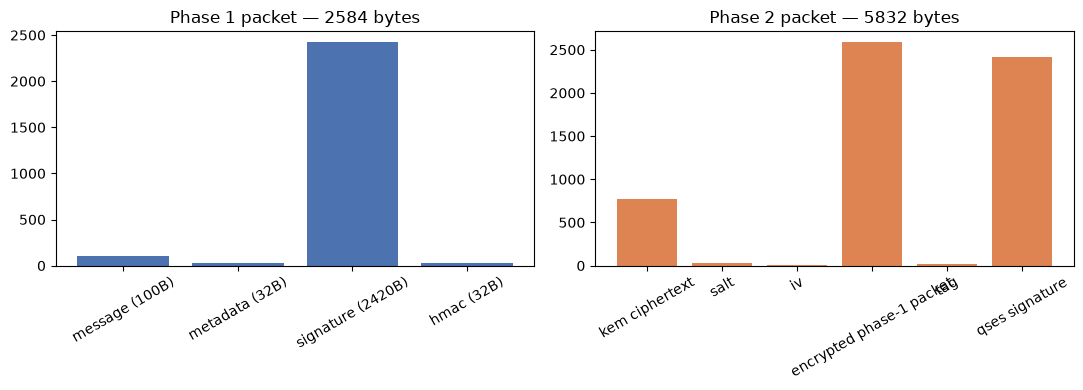

In [6]:
import matplotlib.pyplot as plt

phase1_components = {
    "message (100B)": len(client_packet.message),
    "metadata (32B)": len(client_packet.meta),
    "signature (2420B)": len(client_packet.signature),
    "hmac (32B)": len(client_packet.hmac),
}
phase2_components = {
    "kem ciphertext": len(edge_packet.kem_ciphertext),
    "salt": len(edge_packet.salt),
    "iv": len(edge_packet.iv),
    "encrypted phase-1 packet": len(edge_packet.ciphertext),
    "tag": len(edge_packet.tag),
    "qses signature": len(edge_packet.signature),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(phase1_components.keys(), phase1_components.values(), color="#4C72B0")
axes[0].set_title(f"Phase 1 packet — {sum(phase1_components.values())} bytes")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(phase2_components.keys(), phase2_components.values(), color="#DD8452")
axes[1].set_title(f"Phase 2 packet — {sum(phase2_components.values())} bytes")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Security demonstration

The same network above is now attacked three different ways. Each attack is
rejected by a different layer of the protocol — that's the point of having
several independent checks.

### Attack 1 — Replaying a captured packet

An attacker captures a legitimate Phase-2 packet off the wire and resends it
later, hoping the server accepts the same reading twice.

In [7]:
# send one more genuine reading so we have a packet to replay without disturbing stored history
fresh_edge_packet = qses.process_and_forward(client.create_signed_reading(b"SpO2: 98"))
server.receive_and_verify(fresh_edge_packet)
print("Baseline reading accepted. Now replaying the exact same packet...\n")

try:
    server.receive_and_verify(fresh_edge_packet)
    print("!! replay was NOT caught (this would be a bug)")
except ProtocolError as e:
    print(f"[REJECTED] {e}")

Baseline reading accepted. Now replaying the exact same packet...

[REJECTED] replayed client nonce


### Attack 2 — Flipping one bit in transit

An attacker on the QSES-to-Server link flips a single bit of the ciphertext.
The QSES signature covers the ciphertext, so this is caught before
decryption is even attempted.

In [8]:
bad_ciphertext = bytes([fresh_edge_packet.ciphertext[0] ^ 1]) + fresh_edge_packet.ciphertext[1:]
tampered = EdgePacket(fresh_edge_packet.kem_ciphertext, fresh_edge_packet.salt,
                       fresh_edge_packet.iv, bad_ciphertext,
                       fresh_edge_packet.tag, fresh_edge_packet.signature)

try:
    server.receive_and_verify(tampered)
    print("!! tampering was NOT caught (this would be a bug)")
except ProtocolError as e:
    print(f"[REJECTED] {e}")

[REJECTED] invalid QSES transport signature


### Attack 3 — A compromised QSES forges the HMAC

This is the interesting one: QSES itself tries to alter a reading before
forwarding it. QSES *can* still produce a valid signature and a valid
AES-GCM encryption (it legitimately holds those keys) — but it does **not**
know the device's `hmac_key`, so it cannot produce a matching HMAC. Only the
Medical Server, which also holds that key, can catch this.

In [9]:
genuine = client.create_signed_reading(b"Heart rate: 78")
forged = ClientPacket(genuine.message, genuine.meta, genuine.signature, b"\x00" * 32)  # QSES corrupts the HMAC

malicious_edge_packet = qses.process_and_forward(forged)   # QSES's own checks still pass!
print("QSES forwarded the forged packet without noticing anything wrong.\n")

try:
    server.receive_and_verify(malicious_edge_packet)
    print("!! forged HMAC was NOT caught (this would be a bug)")
except MaliciousEdgeError as e:
    print(f"[REJECTED] {e}")
    print(f"server.qses_flagged = {server.qses_flagged}")

QSES forwarded the forged packet without noticing anything wrong.

[REJECTED] HMAC mismatch after valid device signature
server.qses_flagged = True
